In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
import time


In [12]:

df = pd.read_csv("/content/customer_feedback - customer_feedback.csv")
print(df.head())

                                          Feedback           Category
0            Wrong color received and I need help.            Product
1        Gift wrapping available for order #82633.    General Inquiry
2   Checkout page not loading for my recent order.  Technical Support
3        Package not received on my first attempt.           Delivery
4  Password reset not working as soon as possible.  Technical Support


In [13]:
print(df.info())
print(df["Category"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Feedback  1000 non-null   object
 1   Category  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
None
Category
Product              200
General Inquiry      200
Technical Support    200
Delivery             200
Billing              200
Name: count, dtype: int64


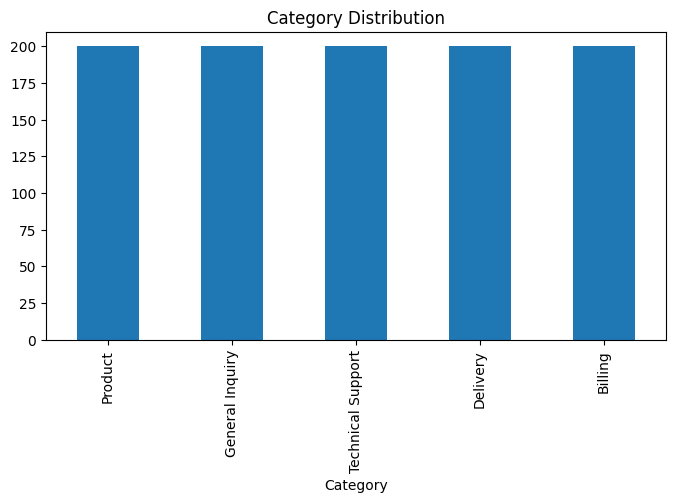

In [3]:
df["Category"].value_counts().plot(kind="bar", figsize=(8,4))
plt.title("Category Distribution")
plt.show()




In [8]:
pip install wordcloud

In [5]:
department={
    "Billing":"Finance Team",
    "Delivery":"Logistics Team",
    "Product":"Quality Assurance Team",
    "Technical Support":"IT Support Team",
    "General Inquiry":"Customer Care Team"
}

priority_keywords=[
    "urgent","immediately","critical","refund",
    "error","failed","not working"
]

def detect_priority(msg):
    msg=msg.lower()
    return "HIGH" if any(k in msg for k in priority_keywords) else "NORMAL"

def route_message(msg):
    category=model.predict([msg])[0]
    team=department.get(category,"Customer Care")
    print("Message:",msg)
    print("Category:",category)
    print("Priority:",detect_priority(msg))
    print("Route:",team)
    print("-"*40)

stream=[
"My payment failed and money deducted",
"Package has not arrived",
"Need refund immediately",
"Password reset not working"
]

for m in stream:
    route_message(m)
    time.sleep(1)


Message: My payment failed and money deducted
Category: Billing
Priority: HIGH
Route: Finance Team
----------------------------------------
Message: Package has not arrived
Category: Delivery
Priority: NORMAL
Route: Logistics Team
----------------------------------------
Message: Need refund immediately
Category: Billing
Priority: HIGH
Route: Finance Team
----------------------------------------
Message: Password reset not working
Category: Technical Support
Priority: HIGH
Route: IT Support Team
----------------------------------------


Accuracy: 1.0
                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        36
         Delivery       1.00      1.00      1.00        49
  General Inquiry       1.00      1.00      1.00        35
          Product       1.00      1.00      1.00        34
Technical Support       1.00      1.00      1.00        46

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



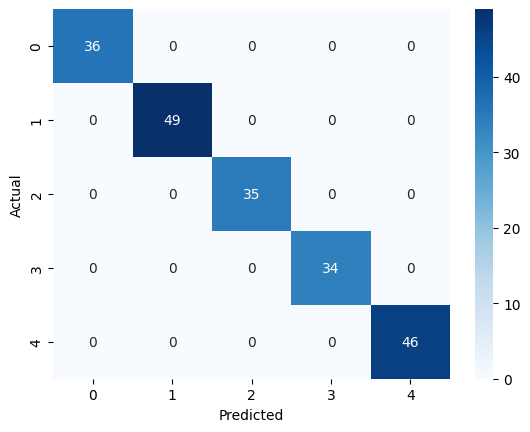

In [9]:
X=df["Feedback"]
y=df["Category"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

model=Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("nb",MultinomialNB())
])

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


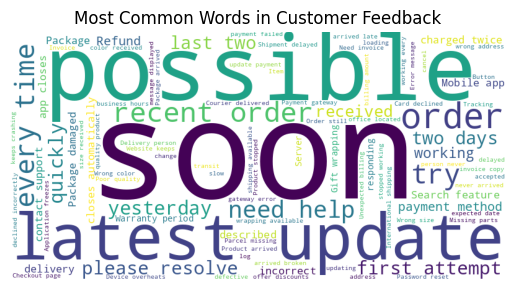

In [10]:
wc = WordCloud(width=800,height=400,background_color="white").generate(" ".join(df["Feedback"]))
plt.imshow(wc)
plt.axis("off")

plt.title("Most Common Words in Customer Feedback")
plt.show()